# Time Series Naive
**Author:** Alejandro Orellana

**Date:** Feburary 4, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

**Purpose:** Starting initial time series with naive structure 

## Section 1: Loading Data

In [2]:
from utils.data_utils import load_data, load_neighborhood_geojson
from utils.fix_effect_utils import ols_compare_and_pred_plot, prepared_dataframe

geojson_data = load_neighborhood_geojson()
analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"

2026-03-01 00:54:56,822 [INFO] Loading GeoJSON from: /project/data/chicago_geo/neighborhood_chi.geojson
2026-03-01 00:54:56,864 [INFO] Loaded 98 features
2026-03-01 00:54:57,425 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-03-01 00:54:57,428 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


In [3]:
missing_counts = analysis_df.groupby("ID").agg(
    Missing_Data=("Site EUI (kBtu/sq ft)", lambda x: x.isna().sum())
)
dropping_list = missing_counts[missing_counts["Missing_Data"] > 0].index
model_data = analysis_df.copy()
print(f"Orignal # of buildings: {len(model_data.ID.unique())}")
model_data = model_data.drop(model_data[model_data["ID"].isin(dropping_list)].index)
print(f"New # of full history buildings: {len(model_data.ID.unique())}")
model_data = model_data.sort_values(["ID", "Data Year"])
print(f"New # of multifamily housing buildings: {len(model_data.ID.unique())}")

Orignal # of buildings: 1280
New # of full history buildings: 1214
New # of multifamily housing buildings: 1214


# Data Manipulation

In [4]:
remove_year = 2016
cut_off_year = 2023
model_data["Site_EUI_Lag1"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(1)

model_data = model_data[model_data["Data Year"] != remove_year]

train_df = model_data[model_data["Data Year"] < cut_off_year]
test_df = model_data[model_data["Data Year"] == cut_off_year]
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")
print(model_data["Data Year"].unique())

Training Samples: 7284 | Testing Samples: 1214
[2017 2018 2019 2020 2021 2022 2023]


Doing a test/train split for the Naive model

# OLS Modeling and Plotting

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.842
Model:                                    OLS   Adj. R-squared:                  0.842
Method:                         Least Squares   F-statistic:                 3.875e+04
Date:                        Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                                01:11:00   Log-Likelihood:                -32078.
No. Observations:                        7284   AIC:                         6.416e+04
Df Residuals:                            7282   BIC:                         6.417e+04
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

/project/src/utils/fix_effect_utils.py:339: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


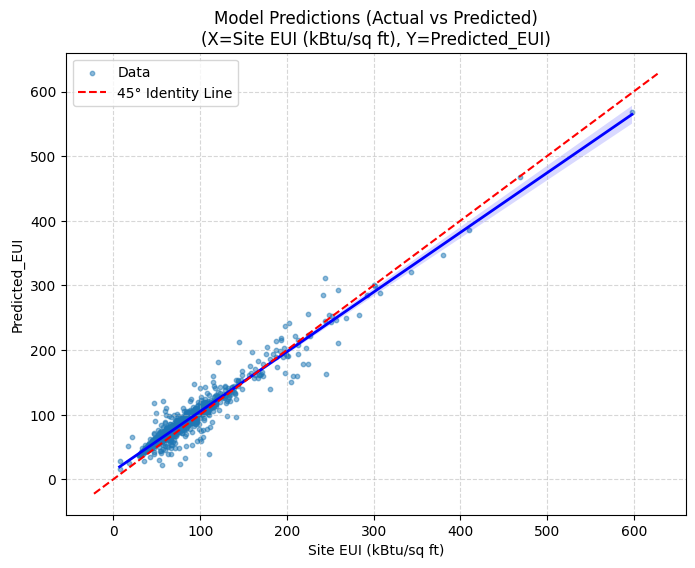

In [4]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ Site_EUI_Lag1"
x_var = "Site EUI (kBtu/sq ft)"
y_var = "Site_EUI_Lag1"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

Through the naive design it shows the expected result that the previous the site EUI can predict the future site EUI. This consistancy shows that buildings have a trend that can be generalized as a lot of the building data points are clumped together.